In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [94]:
df = pd.read_csv(r"D:\SLA\Projects\Customer-ProjectData.csv")
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53.0,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14.0,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64.0,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2.0,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73.0,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23.0,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90.0,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49.0,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49.0,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31.0,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28.0,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32.0,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49.0,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41.0,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33.0,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24.0,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77.0,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24.0,Venmo,Weekly


In [95]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53.0,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14.0,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64.0,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2.0,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73.0,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23.0,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90.0,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49.0,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49.0,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31.0,PayPal,Annually


In [96]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28.0,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32.0,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49.0,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41.0,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33.0,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24.0,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77.0,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24.0,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81.0,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33.0,Venmo,Quarterly


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3899 non-null   object 
 3   Item Purchased          3899 non-null   object 
 4   Category                3899 non-null   object 
 5   Purchase Amount (USD)   3898 non-null   float64
 6   Location                3897 non-null   object 
 7   Size                    3899 non-null   object 
 8   Color                   3899 non-null   object 
 9   Season                  3898 non-null   object 
 10  Review Rating           3862 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3899 non-null   object 
 13  Discount Applied        3899 non-null   object 
 14  Promo Code Used         3898 non-null   

In [98]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3898.000000,3862.000000,3899.000000
mean,1950.500000,44.068462,59.768343,3.749845,25.347012
std,1125.977353,15.207589,23.682919,0.716945,14.446212
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [99]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [100]:
df.columns = df.columns.str.lower().str.replace(" ","_").str.replace("(","").str.replace(")","")

In [101]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [102]:
df.dtypes

customer_id                 int64
age                         int64
gender                     object
item_purchased             object
category                   object
purchase_amount_usd       float64
location                   object
size                       object
color                      object
season                     object
review_rating             float64
subscription_status        object
shipping_type              object
discount_applied           object
promo_code_used            object
previous_purchases        float64
payment_method             object
frequency_of_purchases     object
dtype: object

In [103]:
df.isnull().sum()

customer_id                0
age                        0
gender                     1
item_purchased             1
category                   1
purchase_amount_usd        2
location                   3
size                       1
color                      1
season                     2
review_rating             38
subscription_status        0
shipping_type              1
discount_applied           1
promo_code_used            2
previous_purchases         1
payment_method             2
frequency_of_purchases     0
dtype: int64

In [104]:
freqgraph = df.select_dtypes(include=['float'])
freqgraph

,purchase_amount_usd,review_rating,previous_purchases
0,53.0,3.1,14.0
1,64.0,3.1,2.0
2,73.0,3.1,23.0
3,90.0,3.5,49.0
4,49.0,2.7,31.0
...,...,...,...
3895,28.0,4.2,32.0
3896,49.0,4.5,41.0
3897,33.0,2.9,24.0
3898,77.0,3.8,24.0


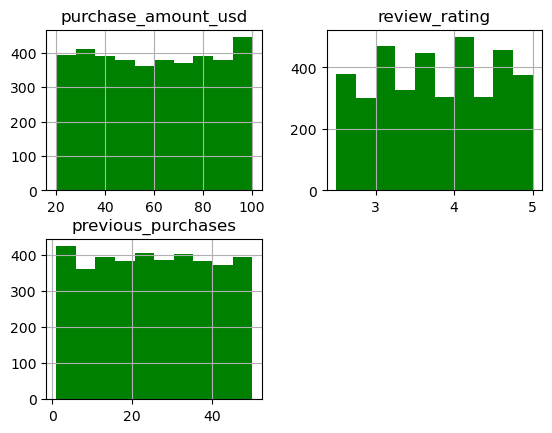

In [105]:
freqgraph.hist(color="g");

In [106]:
for i in ['purchase_amount_usd','review_rating','previous_purchases']:
          df[i]=df[i].fillna(df[i].mean())
df[i]

0       14.0
1        2.0
2       23.0
3       49.0
4       31.0
        ... 
3895    32.0
3896    41.0
3897    24.0
3898    24.0
3899    33.0
Name: previous_purchases, Length: 3900, dtype: float64

In [128]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [109]:
df.duplicated().sum()

np.int64(0)

In [129]:
df.isnull().sum()

customer_id                0
age                        0
gender                     0
item_purchased             0
category                   0
purchase_amount_usd        0
location                   0
size                       0
color                      0
season                     0
review_rating              0
subscription_status        0
shipping_type              0
discount_applied           0
promo_code_used            0
previous_purchases         0
payment_method             0
frequency_of_purchases     0
age_group                  0
purchase_frequency_days    0
dtype: int64

In [110]:
labels = ['young adult','adult','middle-aged','senior']
df['age_group'] = pd.qcut(df['age'],q=4, labels = labels)

In [111]:
df[['age','age_group']].head(10)

,age,age_group
0,55,middle-aged
1,19,young adult
2,50,middle-aged
3,21,young adult
4,45,middle-aged
5,46,middle-aged
6,63,senior
7,27,young adult
8,26,young adult
9,57,middle-aged


In [112]:
frequency_mapping = {
    'Annually': 365,
    'Bi-Weekly': 14,
    'Every 3 Months': 90,
    'Fortnightly': 14,
    'Monthly': 30,
    'Quarterly': 90,
    'Weekly' : 7
}
df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)    

In [113]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [135]:
df.to_csv("customer_data_analysis.csv", index=False)

In [136]:
df.to_csv("D:\SLA\Projects\Final project\Customer Project Data\Python output\customer_data_analysis.csv", index = False)

Text(0.5, 1.0, 'Subscription Status by Gender')

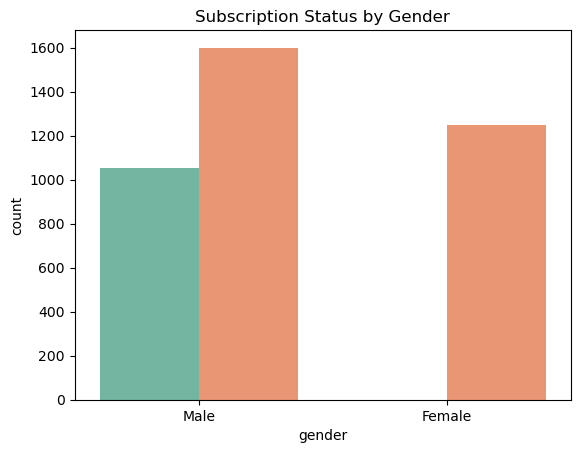

In [118]:
sns.countplot(x='gender',hue='subscription_status', palette="Set2",data=df,legend=False)
plt.title("Subscription Status by Gender")

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Accessories'),
  Text(1, 0, 'Clothing'),
  Text(2, 0, 'Footwear'),
  Text(3, 0, 'Outerwear')])

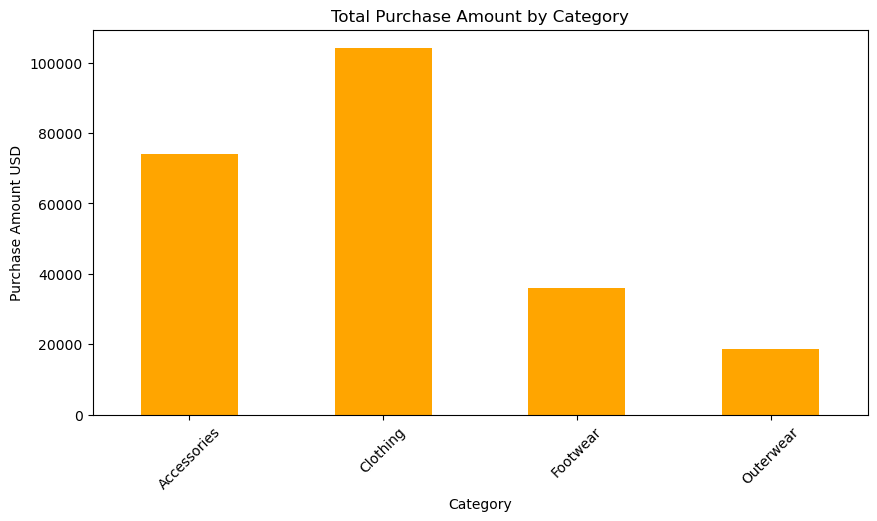

In [119]:
df.groupby('category')['purchase_amount_usd'].sum().plot(
    kind='bar',
    figsize=(10,5),
    color='orange'
)

plt.title('Total Purchase Amount by Category')
plt.xlabel('Category')
plt.ylabel('Purchase Amount USD')

plt.xticks(rotation=45)

Text(0.5, 1.0, 'Season-Wise Purchases')

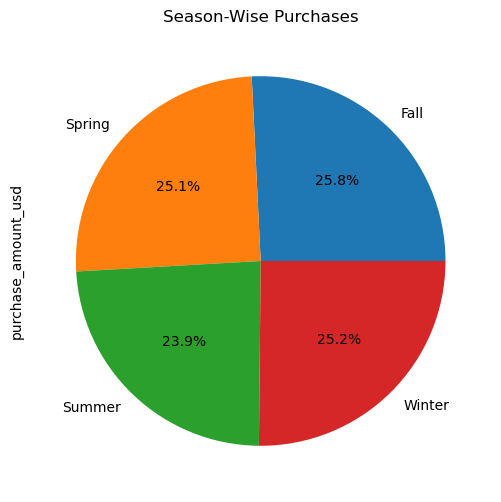

In [120]:
df.groupby('season')['purchase_amount_usd'].sum().plot(
    kind = 'pie', 
    autopct = '%1.1f%%',
    figsize=(6,6)
)
plt.title('Season-Wise Purchases')

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'PayPal'),
  Text(1, 0, 'Credit Card'),
  Text(2, 0, 'Cash'),
  Text(3, 0, 'Debit Card'),
  Text(4, 0, 'Venmo'),
  Text(5, 0, 'Bank Transfer')])

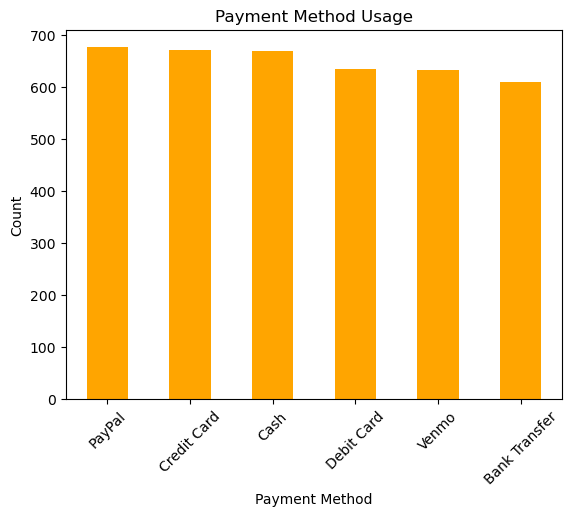

In [121]:
df['payment_method'].value_counts().plot(
    kind = 'bar',
    color = 'Orange'
)
plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Count')

plt.xticks(rotation = 45)

Text(0.5, 1.0, 'Subscription Status')

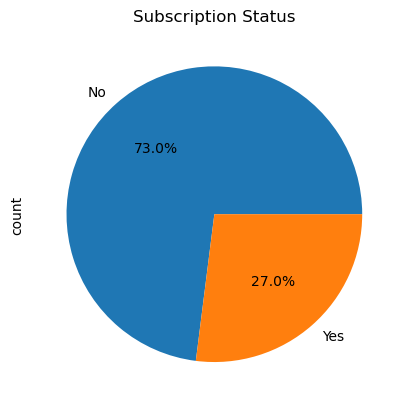

In [122]:
df['subscription_status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Subscription Status')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Montana'),
  Text(1, 0, 'Illinois'),
  Text(2, 0, 'California'),
  Text(3, 0, 'Idaho'),
  Text(4, 0, 'Nevada'),
  Text(5, 0, 'Alabama'),
  Text(6, 0, 'New York'),
  Text(7, 0, 'North Dakota'),
  Text(8, 0, 'West Virginia'),
  Text(9, 0, 'Nebraska')])

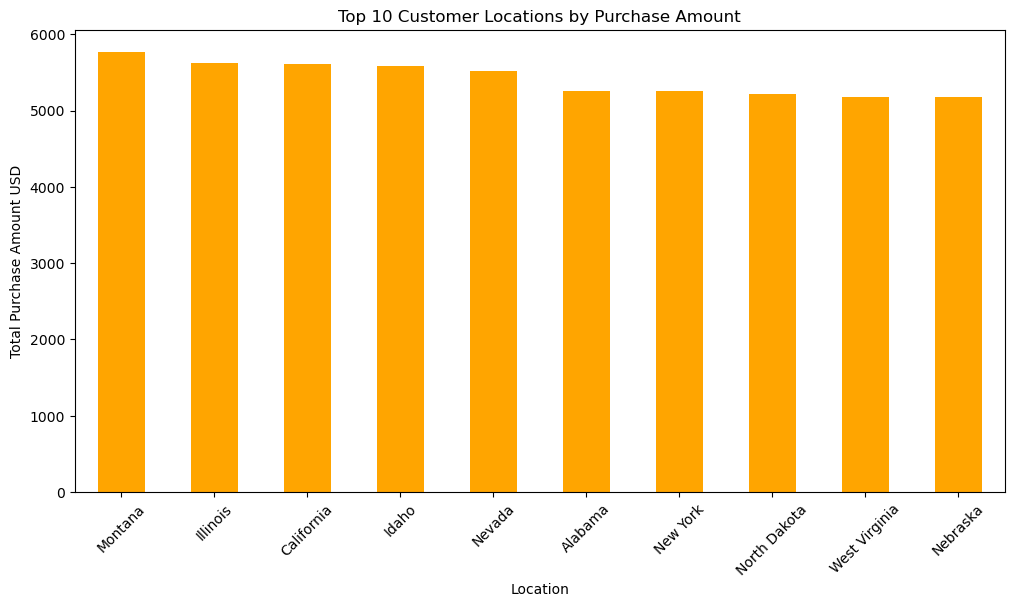

In [123]:
df.groupby('location')['purchase_amount_usd'].sum()\
.sort_values(ascending=False)\
.head(10)\
.plot(kind='bar', figsize=(12,6), color='orange')

plt.title('Top 10 Customer Locations by Purchase Amount')
plt.xlabel('Location')
plt.ylabel('Total Purchase Amount USD')

plt.xticks(rotation=45)

In [124]:
corr = df.select_dtypes(include=['int','float']).corr()

Text(0.5, 1.0, 'Correlation Heatmap')

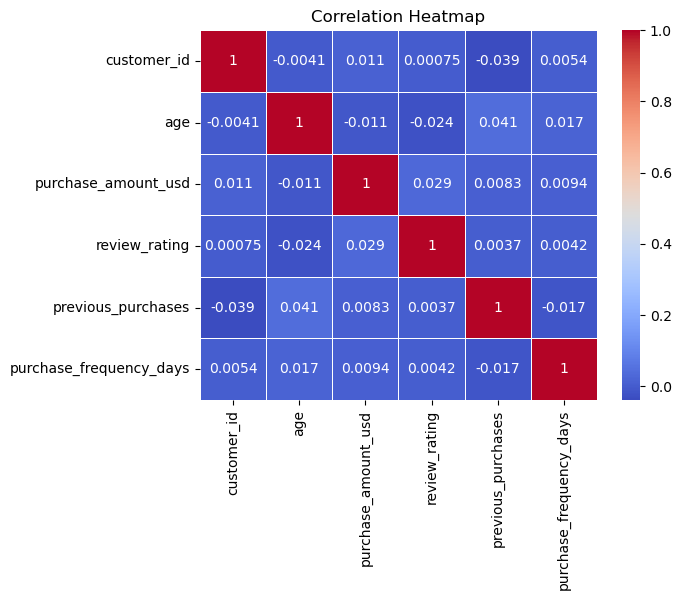

In [125]:
sns.heatmap(corr, cmap="coolwarm", annot=True, linewidths=0.5, linecolor='white')
plt.title("Correlation Heatmap")